# Partie 1 - Prédiction de la survenue (ou pas) d'exacerbations

Talha SOYLU - Dorsa AGHAJANI - Issa ABAKAR

## 1. Importer les données

In [1]:
import polars as pl

In [2]:
chemin1 = "/Users/talhasoylu/Downloads/Data Challenge 2/"

In [3]:
df=pl.read_csv(chemin1 + "trainData.csv")

In [4]:
df.head(3)

patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,gerd,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
1073754155,"""14""","""1""","""1""",0,"""0""","""0""","""1""","""0""","""1""","""0""","""0""","""NA""","""1224.7674731""","""1""","""314""","""218.13""","""0""","""NA""","""7.1105062871""","""5.3850912153"""
1073799394,"""NA""","""1""","""2""",2,"""0""","""1""","""1""","""0""","""0""","""0""","""1""","""NA""","""20290.534269""","""0""","""NA""","""44.98""","""0""","""0""","""9.9179097641""","""3.8062179465"""
1073854918,"""62""","""1""","""NA""",0,"""0""","""0""","""NA""","""0""","""0""","""0""","""0""","""0.7384196185""","""2964.2541751""","""NA""","""480""","""99.26""","""0""","""0""","""7.9943807368""","""4.5977426702"""


## 2. Partitionner les données

In [5]:
import sklearn as skl 

In [6]:
df.columns

['patid',
 'index_age',
 'previous_asthma_drugs',
 'total_pre_index_cannisters_365',
 'post_index_exacerbations365',
 'pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis',
 'adherence',
 'total_pre_index_charge',
 'pre_asthma_days',
 'pre_asthma_charge',
 'pre_asthma_pharma_charge',
 'drug_s',
 'female',
 'log_charges',
 'log_asthma_charge']

In [7]:
target = df.select(['post_index_exacerbations365'])

## 3. Prépaer les données

## Extraire les features

In [8]:
target.head(3)

post_index_exacerbations365
i64
0
2
0


In [9]:
features = df.select([
 'index_age',
 'previous_asthma_drugs',
 'total_pre_index_cannisters_365',
 'pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis',
 'adherence',
 'total_pre_index_charge',
 'pre_asthma_days',
 'pre_asthma_charge',
 'pre_asthma_pharma_charge',
 'drug_s',
 'female',
])

In [10]:
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split( features, target, test_size=0.2, random_state=42, )

In [11]:
X_train.head(3)

index_age,previous_asthma_drugs,total_pre_index_cannisters_365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,gerd,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""18""","""1""","""NA""","""0""","""0""","""NA""","""0""","""0""","""0""","""1""","""0.4959128065""","""15132.127497""","""2""","""883""","""1007.78""","""1""","""1"""
"""21""","""1""","""1""","""0""","""1""","""0""","""0""","""1""","""0""","""1""","""0.0844686649""","""2674.9944611""","""3""","""362""","""21.41""","""0""","""0"""
"""53""","""1""","""0""","""1""","""0""","""0""","""0""","""0""","""0""","""0""","""0.6920980926""","""1907.8437372""","""0""","""0""","""225.82""","""0""","""1"""


In [12]:
X_train.group_by(
    pl.col('previous_asthma_drugs'),
    maintain_order=True,
).len(
)

previous_asthma_drugs,len
str,u32
"""1""",10513
"""NA""",1147


In [13]:
X_train.group_by(
    pl.col('pneumonia'),
    maintain_order=True,
).len(
)

pneumonia,len
str,u32
"""0""",9935
"""1""",520
"""NA""",1205


In [14]:
categorical_features = [
 'previous_asthma_drugs',
 'pneumonia',
 'sinusitis',
 'acute_bronchitis',
 'acute_laryngitis',
 'upper_respiratory_infection',
 'gerd',
 'rhinitis',
 'drug_s',
 'female',
]

In [15]:
encoder = skl.preprocessing.OneHotEncoder()

In [16]:
encoder.fit(X_train.select(categorical_features))  # fit encoder to categorical features

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

In [17]:
encoder.categories_

[array(['1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object),
 array(['0', '1', 'NA'], dtype=object)]

In [18]:
encoder.feature_names_in_

array(['previous_asthma_drugs', 'pneumonia', 'sinusitis',
       'acute_bronchitis', 'acute_laryngitis',
       'upper_respiratory_infection', 'gerd', 'rhinitis', 'drug_s',
       'female'], dtype=object)

In [19]:
numeric_features_int = [
 'index_age',
 'total_pre_index_cannisters_365',
 'pre_asthma_days',
 'pre_asthma_charge',
]

In [20]:
numeric_features_float = [
 'adherence',
 'total_pre_index_charge',
 'pre_asthma_pharma_charge',
]

In [21]:
assert (
    len(categorical_features) +
    len(numeric_features_int) +
    len(numeric_features_float) == len(features.columns)
)

In [22]:
scaler = skl.preprocessing.StandardScaler()

In [23]:
X_train_float = X_train.select(
    numeric_features_float
).cast(
    pl.Float64, strict=False
)

In [24]:
X_train_float.sample(
    n=5
)

adherence,total_pre_index_charge,pre_asthma_pharma_charge
f64,f64,f64
1.0,1612.194379,1684.71
0.084469,5416.688058,null
0.250681,260.559136,231.09
0.13079,6760.852888,1263.81
0.168937,97.358701,null


In [25]:
scaler.fit(X_train_float)  # compute mean and std to be used for later scaling

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [26]:
scaler.feature_names_in_

array(['adherence', 'total_pre_index_charge', 'pre_asthma_pharma_charge'],
      dtype=object)

In [27]:
scaler.mean_

array([2.53409211e-01, 8.49479536e+03, 2.43724927e+02])

In [28]:
scaler.scale_

array([2.30289114e-01, 2.21681733e+04, 4.44651815e+02])

In [29]:
float_transformer = skl.pipeline.Pipeline(  # sequence of data transformers
    steps=[
        # add conversion to float64,
        ('scaler', skl.preprocessing.StandardScaler()),
        # another preprocessing step
    ]
)

int_transformer = skl.pipeline.Pipeline(
    steps=[
        ('scaler', skl.preprocessing.StandardScaler()),
    ]
)

categorical_transformer = skl.pipeline.Pipeline(
    steps=[
        ('encoder', skl.preprocessing.OneHotEncoder()),
    ]
)

In [89]:
preprocessor = skl.compose.ColumnTransformer(  # Appliquer des transformateurs aux colonnes
    transformers=[
        ('num_float', float_transformer, numeric_features_float),
        ('num_int', int_transformer, numeric_features_int),
        ('cat', categorical_transformer, categorical_features),
    ]
)

preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_float', ...), ('num_int', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [90]:
def cast_numeric_int(s):  # fonction personnalisée
    return s.cast(pl.Int64, strict=False)

In [91]:
cast_numeric_int(features['index_age'])

index_age
i64
14
null
62
null
40
…
28
63
34


In [33]:
# Créer un transformateur de données à partir d’une fonction personnalisée
cast_int_transformer = skl.preprocessing.FunctionTransformer(cast_numeric_int)

In [34]:
cast_int_transformer.fit_transform(  # Entraîner sur les données et les transformer
    X_train.select(
        numeric_features_int
    )
)

index_age,total_pre_index_cannisters_365,pre_asthma_days,pre_asthma_charge
i64,i64,i64,i64
18,null,2,883
21,1,3,362
53,0,0,0
31,null,0,0
55,1,0,0
…,…,…,…
null,0,2,657
17,2,0,0
55,0,2,null


In [35]:
int_transformer = skl.pipeline.Pipeline(
    steps=[
        ('caster', cast_int_transformer),
        ('scaler', skl.preprocessing.StandardScaler()),
    ]
)

In [36]:
def cast_numeric_float(s):
    return s.cast(pl.Float64, strict=False)

cast_float_transformer = skl.preprocessing.FunctionTransformer(cast_numeric_float)

float_transformer = skl.pipeline.Pipeline(
    steps=[
        ('caster', cast_float_transformer),
        ('scaler', skl.preprocessing.StandardScaler()),
    ]
)

In [37]:
preprocessor = skl.compose.ColumnTransformer(  # Appliquer des transformateurs aux colonnes
    transformers=[
        ('num_float', float_transformer, numeric_features_float),
        ('num_int', int_transformer, numeric_features_int),
        ('cat', categorical_transformer, categorical_features),
    ]
)

In [38]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_float', ...), ('num_int', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [39]:
preprocessor.fit_transform(X_train)

array([[ 1.05303977,  0.29940817,  1.71832217, ...,  0.        ,
         1.        ,  0.        ],
       [-0.73360197, -0.26252957, -0.49997531, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.90494841, -0.29713552, -0.0402673 , ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.36680797,  0.09351425, -0.32876269, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.05303977, -0.33332881,  0.14072825, ...,  0.        ,
         1.        ,  0.        ],
       [-0.36680797, -0.36040896, -0.49997531, ...,  0.        ,
         0.        ,  1.        ]], shape=(11660, 36))

## Binariser l'outcome

In [40]:
y_train.head(n=5)

post_index_exacerbations365
i64
0
2
0
1
0


In [41]:
def binarize_outcome(df):
    df = df.with_columns(
        pl.when(
            pl.col('post_index_exacerbations365') > 0).then(1).otherwise(0).alias('survenue'),
    )
    return df['survenue']

In [42]:
y_train = binarize_outcome(y_train)
y_train.head(n=5)

survenue
i32
0
1
0
1
0


In [43]:
y_train.shape

(11660,)

In [44]:
y_train.sum()

1298

In [45]:
y_test = binarize_outcome(y_test)  # Appliquer le même prétraitement

## XGBoost — Modèle de classification

In [46]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [47]:
# réglage utile si classe 1 rare
pos = max(int(y_train.sum()), 1)
neg = max(int(len(y_train) - y_train.sum()), 1)
spw = neg / pos

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=spw
)

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb)
])

In [48]:
clf.fit(X_train, y_train) #entrainer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_float', ...), ('num_int', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [49]:
proba_val = clf.predict_proba(X_train)[:, 1]

In [50]:
proba_test = clf.predict_proba(X_test)[:, 1]

In [51]:
pred_test = (proba_test >= 0.5).astype(int)

In [52]:
from sklearn.metrics import f1_score, precision_score
print("F1:", f1_score(y_test, pred_test))
print("Precision:", precision_score(y_test, pred_test))

F1: 0.18330308529945555
Precision: 0.13685636856368563


In [53]:
print("Taux de 1 global:", target.mean())
print("Taux de 1 train:", y_train.mean())
print("Taux de 1 test:", y_test.mean())

Taux de 1 global: shape: (1, 1)
┌─────────────────────────────┐
│ post_index_exacerbations365 │
│ ---                         │
│ f64                         │
╞═════════════════════════════╡
│ 0.175163                    │
└─────────────────────────────┘
Taux de 1 train: 0.11132075471698114
Taux de 1 test: 0.1248713550600343


In [54]:
spw = (len(y_train) - y_train.sum()) / y_train.sum() #mettre du poids 1 compte 8 fois plus 
spw

7.983050847457627

## Optimisation du threshold sur les probabilités (F1 / précision / rappel)

In [55]:
import numpy as np 
from sklearn.metrics import f1_score, precision_score, recall_score

proba = clf.predict_proba(X_test)[:, 1]

best_thr, best_f1, best_prec, best_rec = 0.5, -1, -1, -1

for thr in np.linspace(0.01, 0.99, 99):
    pred = (proba >= thr).astype(int)
    f1 = f1_score(y_test, pred, zero_division=0)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    if (f1 > best_f1) or (np.isclose(f1, best_f1) and prec > best_prec):
        best_thr, best_f1, best_prec, best_rec = thr, f1, prec, rec

print("Best threshold:", best_thr)
print("Best F1:", best_f1)
print("Precision at best:", best_prec)
print("Recall at best:", best_rec)

Best threshold: 0.38
Best F1: 0.23076923076923078
Precision at best: 0.14423076923076922
Recall at best: 0.5769230769230769


In [56]:
y = (pl.col("post_index_exacerbations365") > 0).cast(pl.Int64)

In [57]:
clf.predict_proba(X_test)

array([[0.7804427 , 0.21955732],
       [0.57238615, 0.42761382],
       [0.6146221 , 0.38537788],
       ...,
       [0.3330292 , 0.6669708 ],
       [0.764075  , 0.23592503],
       [0.5394809 , 0.4605191 ]], shape=(2915, 2), dtype=float32)

In [58]:
y_pred = clf.predict(X_test)

In [59]:
skl.metrics.accuracy_score(y_test, y_pred)  # y_test est la vérité terrain

0.6912521440823327

In [60]:
clf.score(X_test, y_test)

0.6912521440823327

In [61]:
X_test.shape

(2915, 17)

In [62]:
y_test.shape

(2915,)

In [63]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [64]:
X_train.shape

(11660, 17)

In [65]:
y_train.shape

(11660,)

In [66]:
11660+2915

14575

In [67]:
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
n_pos, n_neg, spw

(1298, 10362, 7.983050847457627)

In [68]:
cm = skl.metrics.confusion_matrix(y_test, y_pred)
cm

array([[1914,  637],
       [ 263,  101]])

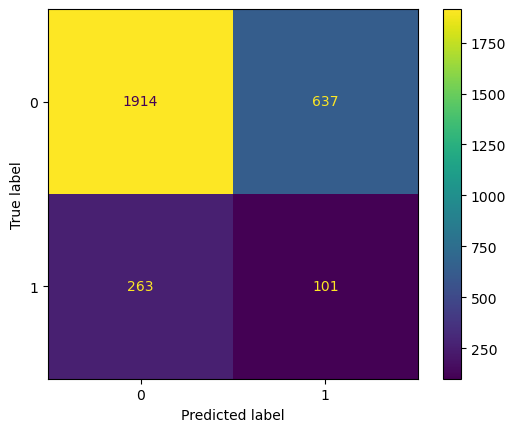

In [69]:
skl.metrics.ConfusionMatrixDisplay(cm).plot()

## Exportation CSV : Patid + Prédiciton

In [93]:
import polars as pl
import numpy as np

df_pred = pl.read_csv("/Users/talhasoylu/Downloads/Data Challenge 2/trainData.csv") #on charge le fichier

patid = df_pred.select(["patid"]) #on conserve patid 

X_pred = df_pred.drop(["post_index_exacerbations365"], strict=False) #Features 

proba = clf.predict_proba(X_pred) # Probabilités de la classe 1 
proba_1 = proba[:, 1]

target_rate = 0.11403087478559176 #Threshold final
t = float(np.quantile(proba_1, 1 - target_rate))
print("Threshold utilisé:", t)

pred = (proba_1 >= t).astype(int)

submission = patid.with_columns(pl.Series("prediction", pred)) # Construire le fichier de soumission + checks

print(submission.head())
print(submission["prediction"].value_counts())
print("Nb lignes:", submission.height)

submission.write_csv("submission.csv") # Export CSV
print("✅ Fichier créé : submission.csv")

Threshold utilisé: 0.600839376449585
shape: (5, 2)
┌────────────┬────────────┐
│ patid      ┆ prediction │
│ ---        ┆ ---        │
│ i64        ┆ i64        │
╞════════════╪════════════╡
│ 1073754155 ┆ 0          │
│ 1073799394 ┆ 1          │
│ 1073854918 ┆ 0          │
│ 1073898249 ┆ 1          │
│ 1073913003 ┆ 0          │
└────────────┴────────────┘
shape: (2, 2)
┌────────────┬───────┐
│ prediction ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 0          ┆ 12913 │
│ 1          ┆ 1662  │
└────────────┴───────┘
Nb lignes: 14575
✅ Fichier créé : submission.csv
